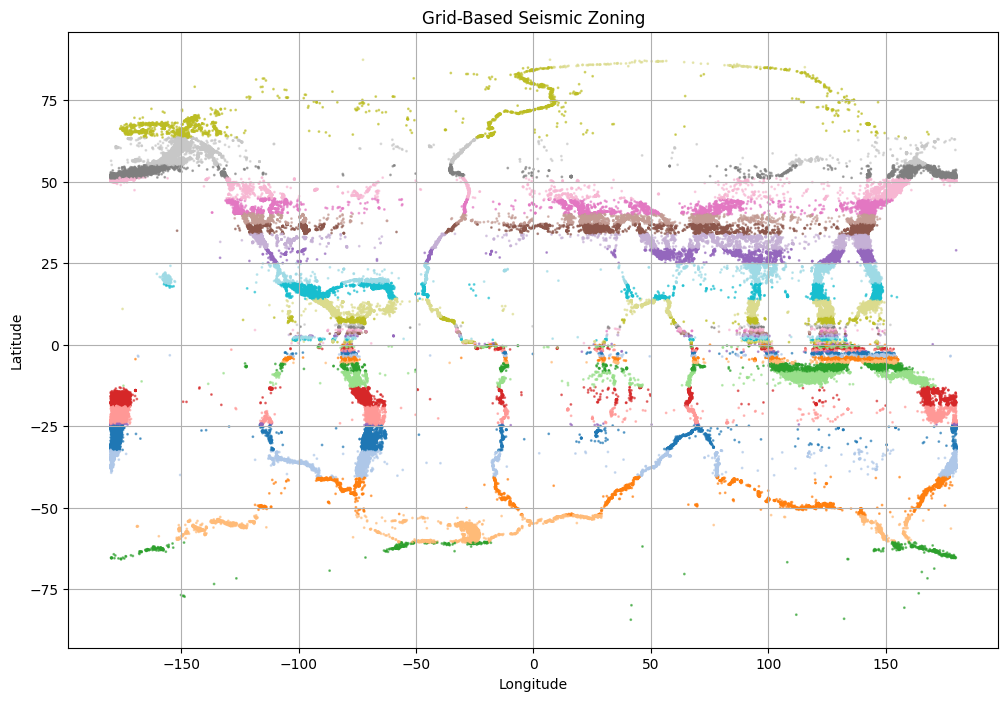

In [1]:
import pandas as pd
import numpy as np

# Load your dataset
df = pd.read_csv("C:/Users/theta/Downloads/cleaned_earthquakes.csv")  # Replace with your actual file path
df = df.drop('seismic_zone', axis=1) # axis=1 indicates dropping a column

# Define grid resolution (in degrees)
grid_size = 0.25  # You can tune this later

# Create grid bins
df['lat_bin'] = np.floor(df['latitude'] / grid_size).astype(int)
df['lon_bin'] = np.floor(df['longitude'] / grid_size).astype(int)

# Create a unique grid ID
df['grid_id'] = df['lat_bin'].astype(str) + '_' + df['lon_bin'].astype(str)

# Group by grid_id and compute both metrics
grid_stats = df.groupby('grid_id').agg({
    'mag': ['max', 'mean', 'count']
}).reset_index()

# Rename columns for clarity
grid_stats.columns = ['grid_id', 'max_mag', 'mean_mag', 'event_count']

# Define weights (you can tune these later)
# w_max = 0.7
# w_mean = 0.3

# # Compute hybrid score
# grid_stats['zone_score'] = w_max * grid_stats['max_mag'] + w_mean * grid_stats['mean_mag'] #for this, the function should have score instead of mag

def assign_seismic_zone(mag):
    if mag < 5.0:
        return 'Low'
    elif 5.0 <= mag < 6.0:
        return 'Moderate'
    elif 6.0 <= mag < 7.0:
        return 'High'
    else:
        return 'Very High'

grid_stats['seismic_zone'] = grid_stats['max_mag'].apply(assign_seismic_zone)
df = df.merge(grid_stats[['grid_id', 'seismic_zone']], on='grid_id', how='left')
# grid_stats['seismic_zone'] = grid_stats['zone_score'].apply(assign_seismic_zone)
# df = df.merge(grid_stats[['grid_id', 'seismic_zone']], on='grid_id', how='left')

import matplotlib.pyplot as plt

# Plot earthquake density by grid
plt.figure(figsize=(12, 8))
plt.scatter(df['longitude'], df['latitude'], c=df['grid_id'].astype('category').cat.codes,
            cmap='tab20', s=1, alpha=0.6)
plt.title('Grid-Based Seismic Zoning')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

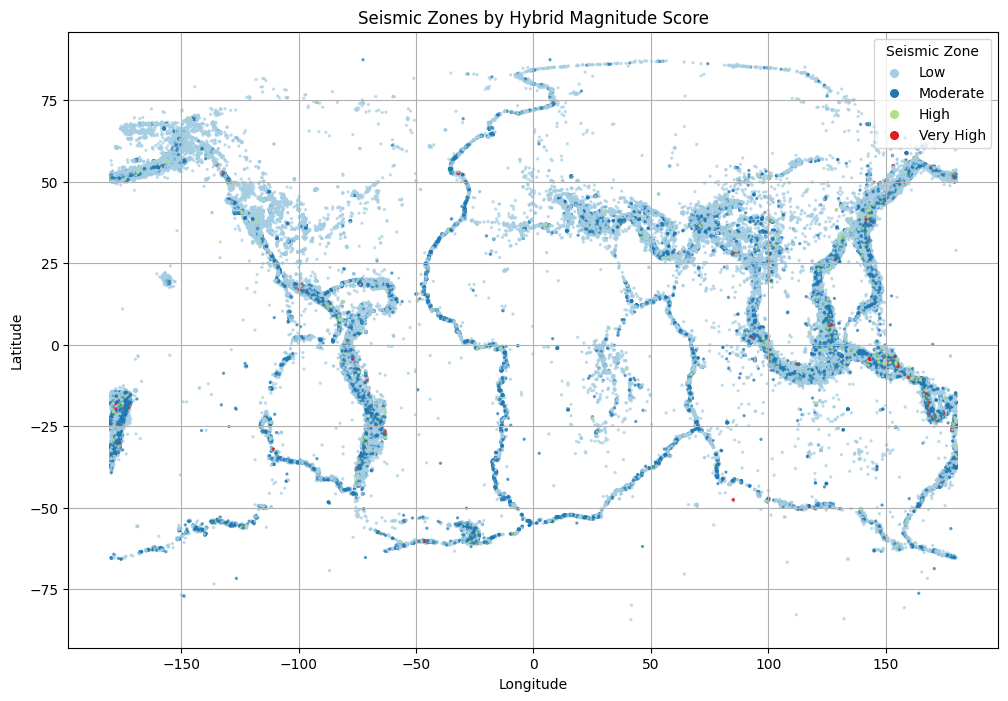

In [2]:
import matplotlib.pyplot as plt

# Define a color map for seismic zones
zone_colors = {
    'Low': '#a6cee3',
    'Moderate': '#1f78b4',
    'High': '#b2df8a',
    'Very High': '#e31a1c'
}

# Map colors to each row
df['zone_color'] = df['seismic_zone'].map(zone_colors)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(df['longitude'], df['latitude'], c=df['zone_color'], s=2, alpha=0.6)
plt.title('Seismic Zones by Hybrid Magnitude Score')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)

# Create legend
for zone, color in zone_colors.items():
    plt.scatter([], [], c=color, label=zone, s=30)
plt.legend(title='Seismic Zone', loc='upper right')

plt.show()

seismic_zone
Low          29881
Moderate      9523
High          1401
Very High      194
Name: count, dtype: int64


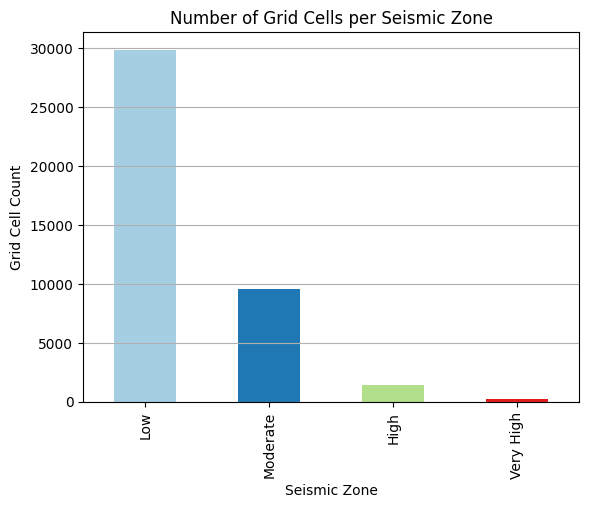

In [3]:
grid_counts = grid_stats['seismic_zone'].value_counts()

zone_order = ['Low', 'Moderate', 'High', 'Very High']
grid_counts = grid_counts.reindex(zone_order)

print(grid_counts)

import matplotlib.pyplot as plt

grid_counts.plot(kind='bar', color=['#a6cee3', '#1f78b4', '#b2df8a', '#e31a1c'])
plt.title('Number of Grid Cells per Seismic Zone')
plt.xlabel('Seismic Zone')
plt.ylabel('Grid Cell Count')
plt.grid(axis='y')
plt.show()

C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:183: UserWarning: [09:03:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


KNN:               precision    recall  f1-score   support

        High       0.87      0.91      0.89      6401
         Low       0.91      0.87      0.89     19490
    Moderate       0.88      0.91      0.89     21510
   Very High       0.88      0.89      0.88      1222

    accuracy                           0.89     48623
   macro avg       0.89      0.89      0.89     48623
weighted avg       0.89      0.89      0.89     48623

Random Forest:               precision    recall  f1-score   support

        High       0.96      0.94      0.95      6401
         Low       0.92      0.93      0.92     19490
    Moderate       0.93      0.93      0.93     21510
   Very High       0.97      0.94      0.96      1222

    accuracy                           0.93     48623
   macro avg       0.95      0.94      0.94     48623
weighted avg       0.93      0.93      0.93     48623

Logistic Regression:               precision    recall  f1-score   support

        High       0.00      0.00 

C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificati

XGBoost:               precision    recall  f1-score   support

        High       0.72      0.36      0.48      6401
         Low       0.72      0.76      0.74     19490
    Moderate       0.66      0.75      0.70     21510
   Very High       0.67      0.33      0.44      1222

    accuracy                           0.69     48623
   macro avg       0.69      0.55      0.59     48623
weighted avg       0.69      0.69      0.68     48623



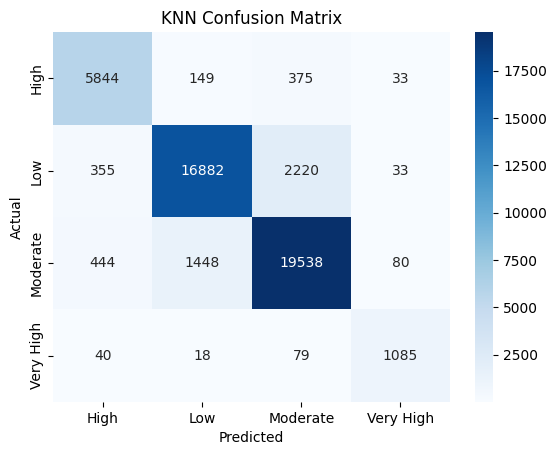

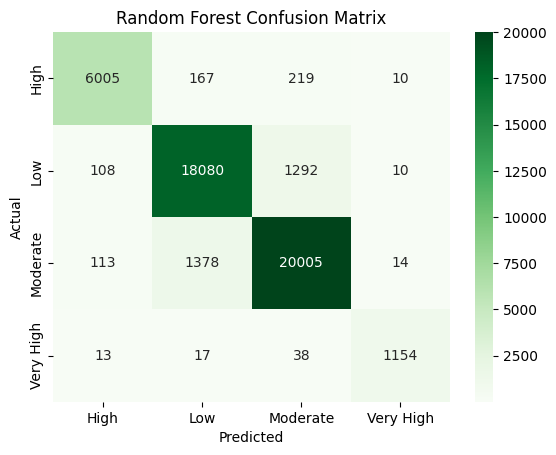

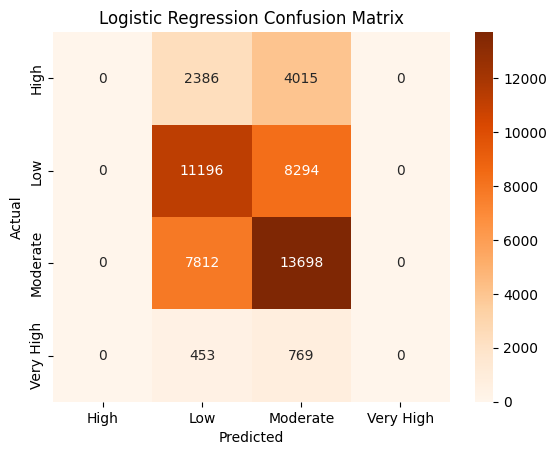

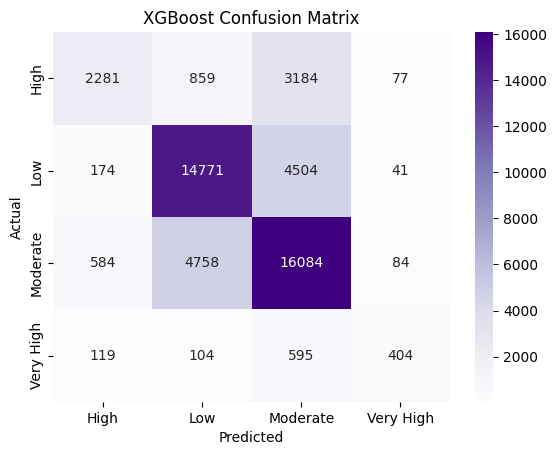

In [4]:
from sklearn.preprocessing import LabelEncoder

# Encode seismic zones as numeric labels
le = LabelEncoder()
df['zone_label'] = le.fit_transform(df['seismic_zone'])

# Features and labels
X = df[['latitude', 'longitude']]
y = df['zone_label']

from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Choose model
modelK = KNeighborsClassifier(n_neighbors=5)
modelR = RandomForestClassifier(n_estimators=100, random_state=42)
modelL = LogisticRegression(max_iter=1000, random_state=42)
modelX = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Train
modelK.fit(X_train, y_train)
modelR.fit(X_train, y_train)
modelL.fit(X_train, y_train)
modelX.fit(X_train, y_train)

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scoring = {
#     'accuracy': make_scorer(accuracy_score),
#     'precision_macro': make_scorer(precision_score, average='macro'),
#     'recall_macro': make_scorer(recall_score, average='macro'),
#     'f1_macro': make_scorer(f1_score, average='macro')
# }

# models = {
#     'KNN': KNeighborsClassifier(n_neighbors=5),
#     'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
#     'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
#     'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
# }

# for name, model in models.items():
#     print(f"\n{name} Cross-Validation Results:")
#     scores = {}
#     for metric in scoring:
#         cv_scores = cross_val_score(model, X, y, cv=cv, scoring=scoring[metric])
#         scores[metric] = cv_scores.mean()
#         print(f"{metric}: {cv_scores.mean():.4f}")


from sklearn.metrics import classification_report

y_predK = modelK.predict(X_test)
report = classification_report(y_test, y_predK, target_names=le.classes_)
print("KNN:", report)

y_predR = modelR.predict(X_test)
report2 = classification_report(y_test, y_predR, target_names=le.classes_)
print("Random Forest:", report2)

y_predL = modelL.predict(X_test)
reportL = classification_report(y_test, y_predL, target_names=le.classes_)
print("Logistic Regression:", reportL)

y_predX = modelX.predict(X_test)
reportX = classification_report(y_test, y_predX, target_names=le.classes_)
print("XGBoost:", reportX)


from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# KNN
cm_knn = confusion_matrix(y_test, y_predK)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Random Forest
cm_rf = confusion_matrix(y_test, y_predR)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_predL)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# XGBoost
cm_xgb = confusion_matrix(y_test, y_predX)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#Not going to use XGBoost or Regression, KNN or Random Classifer work best

C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


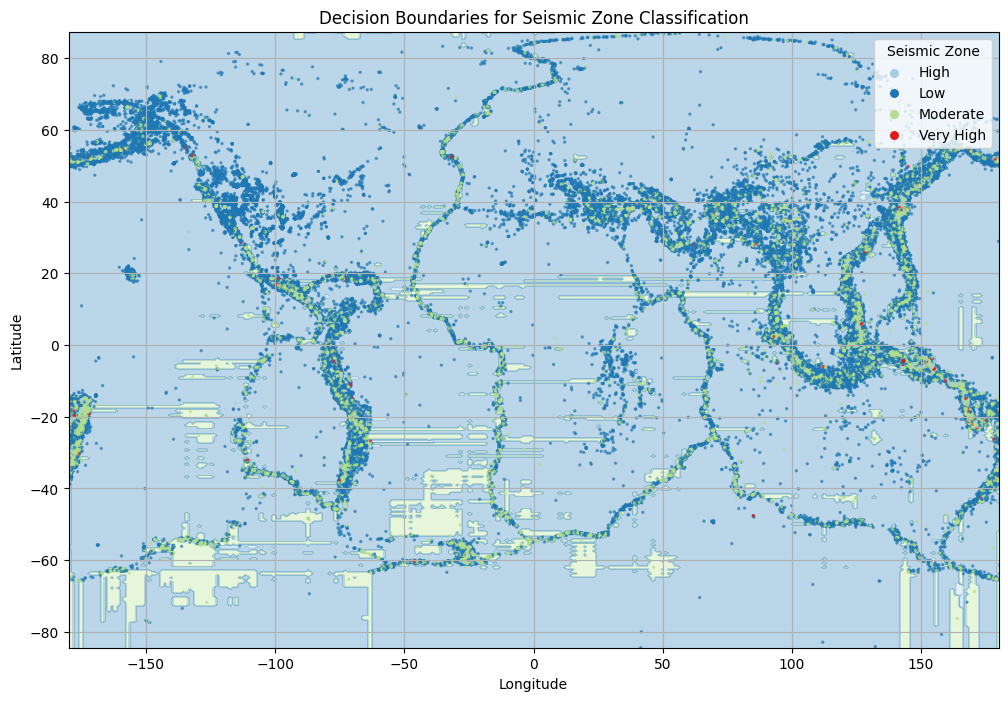

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define bounds based on your data
lat_min, lat_max = df['latitude'].min(), df['latitude'].max()
lon_min, lon_max = df['longitude'].min(), df['longitude'].max()

# Create meshgrid
lat_range = np.linspace(lat_min, lat_max, 300)
lon_range = np.linspace(lon_min, lon_max, 300)
lon_grid, lat_grid = np.meshgrid(lon_range, lat_range)

# Flatten and stack for prediction
grid_points = np.c_[lat_grid.ravel(), lon_grid.ravel()]  # shape: (N, 2) with [lat, lon]

# Predict using your trained model
grid_preds = modelR.predict(grid_points) #switch to modelK for KNN
grid_preds = grid_preds.reshape(lat_grid.shape)  # reshape to match meshgrid

# Define color map
zone_palette = ['#a6cee3', '#1f78b4', '#b2df8a', '#e31a1c']  # Adjust if needed
cmap = ListedColormap(zone_palette[:len(le.classes_)])

# Plot decision boundaries
plt.figure(figsize=(12, 8))
plt.contourf(lon_grid, lat_grid, grid_preds, cmap=cmap, alpha=0.3)

# Overlay actual earthquake points
plt.scatter(df['longitude'], df['latitude'], c=df['zone_label'], cmap=cmap, s=2, alpha=0.6)

# Add legend
for i, zone in enumerate(le.classes_):
    plt.scatter([], [], c=zone_palette[i], label=zone, s=30)
plt.legend(title='Seismic Zone', loc='upper right')

plt.title('Decision Boundaries for Seismic Zone Classification')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

In [10]:

def predict_zone_from_coords(lat, lon, model, label_encoder=le):
    coords = np.array([[lat, lon]])
    label = model.predict(coords)[0]
    zone = label_encoder.inverse_transform([label])[0]
    
    # Optional: confidence score
    if hasattr(model, "predict_proba"):
        confidence = float(np.max(model.predict_proba(coords)))  # Convert np.float64 to native float
    else:
        confidence = None
    
    # Format output
    if confidence is not None:
        print(f"📍 Location ({lat}, {lon}) is classified as '{zone}' with confidence {confidence:.2f}")
    else:
        print(f"📍 Location ({lat}, {lon}) is classified as '{zone}'")

# Example usage

predict_zone_from_coords(50,-21, modelR)
predict_zone_from_coords(50,-21, modelK)




📍 Location (50, -21) is classified as 'Low' with confidence 0.86
📍 Location (50, -21) is classified as 'Low' with confidence 0.80


C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packa

seismic_zone
Low          7473
Moderate      912
High           67
Very High       7
Name: count, dtype: int64
KNN on New Data:
              precision    recall  f1-score   support

        High       0.01      0.03      0.01       567
         Low       0.81      0.55      0.66     14977
    Moderate       0.20      0.39      0.26      3600
   Very High       0.13      0.14      0.14       183

    accuracy                           0.50     19327
   macro avg       0.29      0.28      0.27     19327
weighted avg       0.67      0.50      0.56     19327

Random Forest on New Data:
              precision    recall  f1-score   support

        High       0.01      0.03      0.01       567
         Low       0.82      0.59      0.68     14977
    Moderate       0.21      0.39      0.27      3600
   Very High       0.16      0.16      0.16       183

    accuracy                           0.53     19327
   macro avg       0.30      0.29      0.28     19327
weighted avg       0.67      0

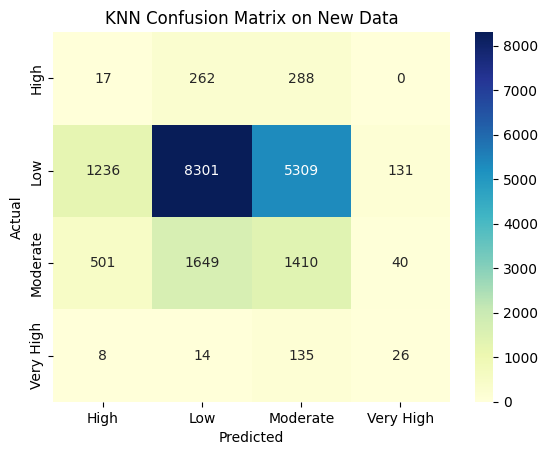

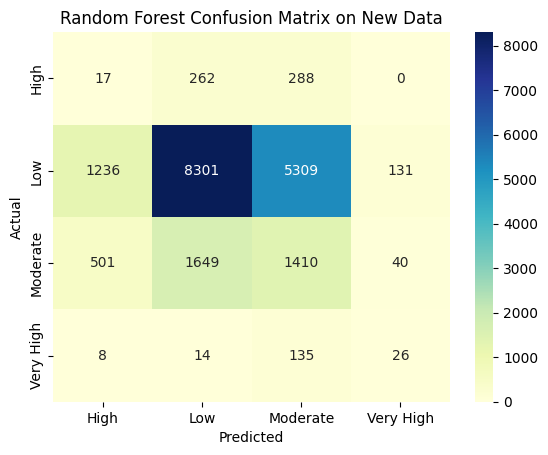

In [8]:
import pandas as pd
import numpy as np

# Load your dataset
df2 = pd.read_csv("C:/Users/theta/Downloads/query (1).csv")  # Replace with your actual file path

# Define grid resolution (in degrees)
grid_size = 0.25  # You can tune this later

# Create grid bins
df2['lat_bin'] = np.floor(df2['latitude'] / grid_size).astype(int)
df2['lon_bin'] = np.floor(df2['longitude'] / grid_size).astype(int)

# Create a unique grid ID
df2['grid_id'] = df2['lat_bin'].astype(str) + '_' + df2['lon_bin'].astype(str)

# Group by grid_id and compute both metrics
grid_stats = df2.groupby('grid_id').agg({
    'mag': ['max', 'mean', 'count']
}).reset_index()

# Rename columns for clarity
grid_stats.columns = ['grid_id', 'max_mag', 'mean_mag', 'event_count']

# Define weights (you can tune these later)
# w_max = 0.7
# w_mean = 0.3

# # Compute hybrid score
# grid_stats['zone_score'] = w_max * grid_stats['max_mag'] + w_mean * grid_stats['mean_mag'] #for this, the function should have score instead of mag

def assign_seismic_zone(mag):
    if mag < 5.0:
        return 'Low'
    elif 5.0 <= mag < 6.0:
        return 'Moderate'
    elif 6.0 <= mag < 7.0:
        return 'High'
    else:
        return 'Very High'

grid_stats['seismic_zone'] = grid_stats['max_mag'].apply(assign_seismic_zone)
df2 = df2.merge(grid_stats[['grid_id', 'seismic_zone']], on='grid_id', how='left')
# grid_stats['seismic_zone'] = grid_stats['zone_score'].apply(assign_seismic_zone)
# df = df.merge(grid_stats[['grid_id', 'seismic_zone']], on='grid_id', how='left')

grid_counts = grid_stats['seismic_zone'].value_counts()

zone_order = ['Low', 'Moderate', 'High', 'Very High']
grid_counts = grid_counts.reindex(zone_order)

print(grid_counts)

# Encode seismic_zone in df2 using the same label encoder
df2['zone_label'] = le.transform(df2['seismic_zone'])  # use the same 'le' from training

# Extract features and labels
X_new = df2[['latitude', 'longitude']]
y_new = df2['zone_label']

y_pred_new = modelK.predict(X_new)
y_pred_newR = modelR.predict(X_new)

from sklearn.metrics import classification_report, confusion_matrix

print("KNN on New Data:")
print(classification_report(y_new, y_pred_new, target_names=le.classes_))

print("Random Forest on New Data:")
print(classification_report(y_new, y_pred_newR, target_names=le.classes_))

cm_new = confusion_matrix(y_new, y_pred_new)
sns.heatmap(cm_new, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('KNN Confusion Matrix on New Data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

cm_newR = confusion_matrix(y_new, y_pred_new)
sns.heatmap(cm_newR, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix on New Data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
